In [2]:
%reset -f

In [3]:
import sys
sys.path.append(r"C:\ThesisWork\offical_approach\mth_project\mth_project\industrial_network_analysis")
from data_preprocessing import Dataset
from data_utils import remove_outliers

import warnings
import logging

warnings_logger = logging.getLogger('warnings')
warnings_logger.setLevel(logging.WARNING)
warning_handler = logging.FileHandler('warnings.log')
warning_handler.setFormatter(logging.Formatter('%(asctime)s - %(levelname)s - %(message)s'))
warnings_logger.addHandler(warning_handler)

def warning_handler_func(message, category, filename, lineno, file=None, line=None):
    warnings_logger.warning(f"{category.__name__}: {message} (File: {filename}, Line: {lineno})")

warnings.showwarning = warning_handler_func

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import timesfm
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

import time
from statsmodels.tsa.api import VAR

 See https://github.com/google-research/timesfm/blob/master/README.md for updated APIs.
Loaded PyTorch TimesFM, likely because python version is 3.11.9 (tags/v3.11.9:de54cf5, Apr  2 2024, 10:12:12) [MSC v.1938 64 bit (AMD64)].


In [4]:
### READ DATA - to get the same dataframe like for pure timesFM, for result comparison

device_name = "A1-RBX-243"
df = Dataset(f'C:\\ThesisWork\\offical_approach\\mth_project\\mth_project\\industrial_network_analysis\\Data082025\\{device_name}.csv')

# names for traffic on ports - BITS SENT/RECEIVED
bits = "bits"
bits_exclude = "unused"

def get_column_names_exclude(df, search_keyword, exclude_keyword):
    df_column_names = df.get_column_names(search_keyword)
    df_column_names_excluded = []

    for col in df_column_names:
        if exclude_keyword.lower() not in col.lower():
            df_column_names_excluded.append(col)

    return df_column_names_excluded


df_columns_bits_names = get_column_names_exclude(df, bits, bits_exclude)

df_bits = df.get_column_values(df_columns_bits_names)
df_bits.columns = df_bits.columns.str.replace('Interface Gi', '')
df_bits.columns = df_bits.columns.str.replace('Valmet SUPV switch connection', '')
df_bits.columns = df_bits.columns.str.replace('Supervisory access', '')
df_bits.columns = df_bits.columns.str.replace('Bits sent', 'out')
df_bits.columns = df_bits.columns.str.replace('Bits received', 'in')
df_bits.columns = df_bits.columns.str.replace('Valmet DNA', '')

df_bits = df_bits[:24*60]
df_bits = remove_outliers(df_bits, 3).dropna()
df_bits_train, df_bits_test = np.split(df_bits, [int(0.8 * len(df_bits))])

In [5]:
# VAR forecasting program

### 1. data preparation

# Initialize scaler
scaler = RobustScaler()

# Fit scaler only on training data
train_data_normalized = pd.DataFrame(
    scaler.fit_transform(df_bits_train),
    columns=df_bits_train.columns,
    index=df_bits_train.index
)

# Apply same transformation to test data
test_data_normalized = pd.DataFrame(
    scaler.transform(df_bits_test),
    columns=df_bits_test.columns,
    index=df_bits_test.index
)


Pure VAR model used for multicast forecasting

In [6]:
### 2. check for optimal parameters for model

# analyze optimal parameters for VAR model: maxlags and ic method
# ic_value - information criterion value, lower is better

#train_data_diff = train_data_normalized.diff().dropna()
train_data_diff = train_data_normalized

maxlags_range = range(1, 31)
ic_methods = ['aic', 'bic', 'fpe', 'hqic']
results = []

for ic in ic_methods:
    for maxlags in maxlags_range:
        try:
            model = VAR(train_data_diff)
            fitted = model.fit(maxlags=maxlags, ic=ic)
            results.append({
                'ic': ic,
                'maxlags': maxlags,
                'selected_lags': fitted.k_ar,
                'ic_value': getattr(fitted, ic)
            })
        except Exception as e:
            print(f"Error occurred for ic={ic}, maxlags={maxlags}: {e}")

results_df = pd.DataFrame(results)
print(f"optimal results for VAR: {results_df}")

best_results_for_VAR = results_df.loc[results_df['ic_value'].idxmin()]

maxlags = best_results_for_VAR['maxlags']
ic = best_results_for_VAR['ic']

### 3. create model VAR for variables from df_bits

VAR_model = VAR(train_data_diff)
VAR_model_fitted = VAR_model.fit(maxlags=maxlags, ic=ic)

### 4. Forecasting

start_time = time.time()

lag_order = VAR_model_fitted.k_ar
VAR_forecast = VAR_model_fitted.forecast(train_data_diff.values[-lag_order:], steps=len(test_data_normalized))
df_VAR_forecast = pd.DataFrame(VAR_forecast, index=test_data_normalized.index, columns=test_data_normalized.columns)

end_time = time.time()
elapsed_time = end_time - start_time

print(f"Pure VAR forecasting time: {elapsed_time:.2f}")

### 5. denormalization and inverse differencing

# inverse differencing

def invert_transformation(df_train, df_forecast):
    """Revert back the differencing to get the forecast to original scale."""
    df_fc = df_forecast.copy()
    columns = df_train.columns
    for col in columns:        
        # Roll back 1st Diff
        df_fc[str(col)] = df_train[col].iloc[-1] + df_fc[col].cumsum()
    return df_fc

#df_VAR_forecast = invert_transformation(train_data_normalized, df_VAR_forecast)

# denormalize predictions to original scale
VAR_forecast_denormalized = pd.DataFrame(
    scaler.inverse_transform(df_VAR_forecast),
    columns=df_VAR_forecast.columns,
    index=df_VAR_forecast.index
)

# also denormalize the test data for comparison
test_data_denormalized = pd.DataFrame(
    scaler.inverse_transform(test_data_normalized),
    columns=test_data_normalized.columns,
    index=test_data_normalized.index
)

### 6. evaluation

def calculate_metrics(actual, predicted, variable_name):
    """Calculate comprehensive metrics for a single variable"""
    mae = mean_absolute_error(actual, predicted)
    mse = mean_squared_error(actual, predicted)
    rmse = np.sqrt(mse)

    return {
        'Variable': variable_name,
        'MAE': mae,
        'MSE': mse,
        'RMSE': rmse
    }

VAR_results = []
for col in VAR_forecast_denormalized.columns:
    actual = test_data_denormalized[col].values
    predicted = VAR_forecast_denormalized[col].values

    metrics = calculate_metrics(actual, predicted, col)
    VAR_results.append(metrics)

VAR_results_df = pd.DataFrame(VAR_results)

optimal results for VAR:        ic  maxlags  selected_lags   ic_value
0     aic        1              1 -41.538044
1     aic        2              2 -44.948053
2     aic        3              3 -45.060625
3     aic        4              4 -45.101525
4     aic        5              5 -45.220899
..    ...      ...            ...        ...
115  hqic       26             22 -48.050350
116  hqic       27             22 -48.050350
117  hqic       28             22 -48.050350
118  hqic       29             22 -48.050350
119  hqic       30             22 -48.050350

[120 rows x 4 columns]
Pure VAR forecasting time: 0.03


In [7]:
# visualization

def plot_single_variable_forecast(variable_idx, train_data_normalized, test_data_denormalized, 
                                 VAR_forecast_denormalized, scaler, results_df):

    if variable_idx >= len(VAR_forecast_denormalized.columns):
        print(f"Variable index {variable_idx} out of range. Max index: {len(VAR_forecast_denormalized.columns)-1}")
        return

    col = VAR_forecast_denormalized.columns[variable_idx]

    # Get full training data (denormalized)
    train_denormalized = pd.DataFrame(
        scaler.inverse_transform(train_data_normalized),
        columns=train_data_normalized.columns,
        index=train_data_normalized.index
    )
    
    plt.figure(figsize=(15, 8))
    
    # Plot training data
    plt.plot(train_denormalized.index, train_denormalized[col], 
             label='Training Data', color='blue', alpha=0.7)
    
    # Plot actual test data
    plt.plot(test_data_denormalized.index, test_data_denormalized[col], 
             label='Actual', color='green', linewidth=2)

    # Plot VAR forecast
    plt.plot(VAR_forecast_denormalized.index, VAR_forecast_denormalized[col],
             label='VAR Forecast', color='red', linewidth=2, linestyle='--')

    # Add vertical line at forecast start
    plt.axvline(x=test_data_denormalized.index[0], color='gray', 
                linestyle=':', alpha=0.7, label='Forecast Start')

    plt.title(f'VAR Forecast vs Actual - {col}', fontsize=14)
    plt.xlabel('Time')
    plt.ylabel('Value')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    # Print metrics for this variable
    metrics = results_df[results_df['Variable'] == col].iloc[0]
    print(f"Metrics for {col}:")
    print(f"MAE: {metrics['MAE']:.4f}, RMSE: {metrics['RMSE']:.4f}")

In [8]:
# Print results
for idx, col in enumerate(VAR_results_df['Variable']):
    print(f"Metrics for {col}:")
    print(f" MAE: {VAR_results_df.loc[idx, 'MAE']:.4f},\n MSE: {VAR_results_df.loc[idx, 'MSE']:.4f},\n RMSE: {VAR_results_df.loc[idx, 'RMSE']:.4f}")

Metrics for 1/1( FIREWALL connection): in:
 MAE: 33.6313,
 MSE: 1354.2049,
 RMSE: 36.7995
Metrics for 1/1( FIREWALL connection): out:
 MAE: 546397.7857,
 MSE: 363854429994.0526,
 RMSE: 603203.4731
Metrics for 1/3(Valmet PRP LAN_A-connection): in:
 MAE: 546392.1462,
 MSE: 363843962123.9045,
 RMSE: 603194.7962
Metrics for 1/3(Valmet PRP LAN_A-connection): out:
 MAE: 33.7853,
 MSE: 2097.3037,
 RMSE: 45.7963
Metrics for 1/4(Valmet PRP LAN_B-connection): in:
 MAE: 4.5607,
 MSE: 28.4956,
 RMSE: 5.3381
Metrics for 1/4(Valmet PRP LAN_B-connection): out:
 MAE: 50.7222,
 MSE: 3932.9247,
 RMSE: 62.7130


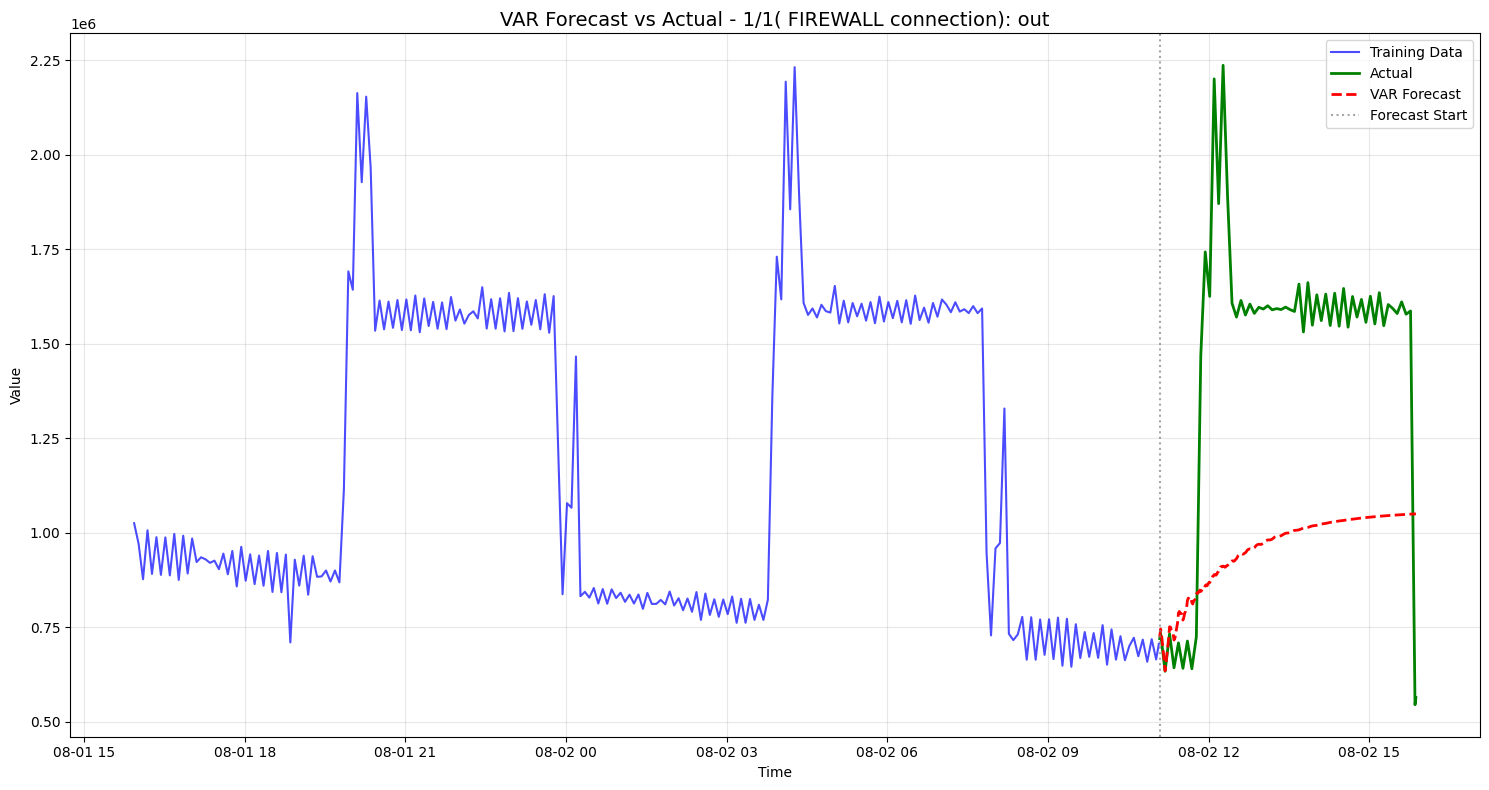

Metrics for 1/1( FIREWALL connection): out:
MAE: 546397.7857, RMSE: 603203.4731


In [9]:
plot_single_variable_forecast(
    variable_idx=1,
    train_data_normalized=train_data_normalized,
    test_data_denormalized=test_data_denormalized,
    VAR_forecast_denormalized=VAR_forecast_denormalized,
    scaler=scaler,
    results_df=VAR_results_df
)

Merged approach, forecasting the residuals using TimesFM.

In [10]:
# add column names to VAR_forecast
VAR_forecast = pd.DataFrame(VAR_forecast, columns=test_data_denormalized.columns)
VAR_forecast.columns = [f"{col}" for col in VAR_forecast.columns]

residuals = {}

# calculate residuals for each variable
for col in VAR_forecast.columns:
    residuals[col] = test_data_denormalized[col].values - VAR_forecast[col].values

In [11]:
# Calculate residuals for each variable in the test set
residuals = test_data_denormalized - VAR_forecast_denormalized
df_residuals = pd.DataFrame(residuals, columns=test_data_denormalized.columns)

In [12]:
# TimesFM model for forecasting values of residuals

context_length = min(512, len(train_data_normalized))  # Use available data or 512
prediction_length = len(df_bits_test)

start_time = time.time()

tfm = timesfm.TimesFm(
    hparams=timesfm.TimesFmHparams(
        context_len=context_length,
        horizon_len=prediction_length,
        backend="cpu",
        per_core_batch_size=32,
        input_patch_len=32,      # fixed
        output_patch_len=128,    # fixed
        num_layers=50,           # fixed
        model_dims=1280,         # fixed
    ),
    checkpoint=timesfm.TimesFmCheckpoint(
        huggingface_repo_id="google/timesfm-2.0-500m-pytorch"),
)

residual_forecast = {}

for i, col in enumerate(train_data_normalized.columns):
    print(f"Processing variable {i+1}/{len(train_data_normalized.columns)}: {col}")
    
    # Prepare data for TimesFM (requires specific format)
    df_input = df_residuals[[col]].reset_index()
    df_input.columns = ["ds", "y"]
    df_input["unique_id"] = col
    
    # Generate forecast
    try:
        forecast_df = tfm.forecast_on_df(
            inputs=df_input,
            freq="1 min",  # adjusted frequency
            value_name="y",
            num_jobs=1,
        )
        
        residual_forecast[col] = forecast_df["timesfm"].values
        print(f"Forecasted {col}")
        
    except Exception as e:
        print(f"Error forecasting {col}: {str(e)}")

# create forecast DataFrame
residual_forecast_df = pd.DataFrame(
    residual_forecast, 
    index=test_data_normalized.index
)

end_time = time.time()
print(f"Forecasting completed in {end_time - start_time:.2f} seconds")


Fetching 5 files: 100%|██████████| 5/5 [00:00<00:00, 4996.79it/s]


Processing variable 1/6: 1/1( FIREWALL connection): in
Processing dataframe with single process.
Finished preprocessing dataframe.
Finished forecasting.
Forecasted 1/1( FIREWALL connection): in
Processing variable 2/6: 1/1( FIREWALL connection): out
Processing dataframe with single process.
Finished preprocessing dataframe.
Finished forecasting.
Forecasted 1/1( FIREWALL connection): out
Processing variable 3/6: 1/3(Valmet PRP LAN_A-connection): in
Processing dataframe with single process.
Finished preprocessing dataframe.
Finished forecasting.
Forecasted 1/3(Valmet PRP LAN_A-connection): in
Processing variable 4/6: 1/3(Valmet PRP LAN_A-connection): out
Processing dataframe with single process.
Finished preprocessing dataframe.
Finished forecasting.
Forecasted 1/3(Valmet PRP LAN_A-connection): out
Processing variable 5/6: 1/4(Valmet PRP LAN_B-connection): in
Processing dataframe with single process.
Finished preprocessing dataframe.
Finished forecasting.
Forecasted 1/4(Valmet PRP LAN_B-

In [13]:
# transform back to original scale from residuals (correct?)
VAR_forecast_with_residuals = test_data_denormalized - residual_forecast_df


In [14]:
### 5. Evaluation

def calculate_metrics(actual, predicted, variable_name):
    """Calculate comprehensive metrics for a single variable"""
    mae = mean_absolute_error(actual, predicted)
    mse = mean_squared_error(actual, predicted)
    rmse = np.sqrt(mse)

    return {
        'Variable': variable_name,
        'MAE': mae,
        'MSE': mse,
        'RMSE': rmse
    }

results = []
for col in VAR_forecast_with_residuals.columns:
    actual = test_data_denormalized[col].values
    predicted = VAR_forecast_with_residuals[col].values

    metrics = calculate_metrics(actual, predicted, col)
    results.append(metrics)

results_df = pd.DataFrame(results)

In [15]:
# visualization

def plot_single_variable_forecast(variable_idx, train_data_normalized, test_data_denormalized, 
                                 forecast_denormalized, scaler, results_df):

    if variable_idx >= len(forecast_denormalized.columns):
        print(f"Variable index {variable_idx} out of range. Max index: {len(forecast_denormalized.columns)-1}")
        return

    col = forecast_denormalized.columns[variable_idx]

    # Get full training data (denormalized)
    train_denormalized = pd.DataFrame(
        scaler.inverse_transform(train_data_normalized),
        columns=train_data_normalized.columns,
        index=train_data_normalized.index
    )
    
    plt.figure(figsize=(15, 8))
    
    # Plot training data
    plt.plot(train_denormalized.index, train_denormalized[col], 
             label='Training Data', color='blue', alpha=0.7)
    
    # Plot actual test data
    plt.plot(test_data_denormalized.index, test_data_denormalized[col], 
             label='Actual', color='green', linewidth=2)
    
    # Plot VAR + TimesFM forecast
    plt.plot(forecast_denormalized.index, forecast_denormalized[col], 
             label='VAR + TimesFM Forecast', color='red', linewidth=2, linestyle='--')
    
    # Add vertical line at forecast start
    plt.axvline(x=test_data_denormalized.index[0], color='gray', 
                linestyle=':', alpha=0.7, label='Forecast Start')
    
    plt.title(f'VAR + TimesFM Forecast vs Actual - {col}', fontsize=14)
    plt.xlabel('Time')
    plt.ylabel('Value')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    # Print metrics for this variable
    metrics = results_df[results_df['Variable'] == col].iloc[0]
    print(f"Metrics for {col}:")
    print(f"MAE: {metrics['MAE']:.4f}, RMSE: {metrics['RMSE']:.4f}")

In [16]:
# Print results

for idx, col in enumerate(results_df['Variable']):
    print(f"Metrics for {col}:")
    print(f" MAE: {results_df.loc[idx, 'MAE']:.4f},\n MSE: {results_df.loc[idx, 'MSE']:.4f},\n RMSE: {results_df.loc[idx, 'RMSE']:.4f}")

Metrics for 1/1( FIREWALL connection): in:
 MAE: 17.6738,
 MSE: 498.8467,
 RMSE: 22.3349
Metrics for 1/1( FIREWALL connection): out:
 MAE: 192014.8157,
 MSE: 76371874109.8441,
 RMSE: 276354.6166
Metrics for 1/3(Valmet PRP LAN_A-connection): in:
 MAE: 191031.5654,
 MSE: 76003674387.0508,
 RMSE: 275687.6392
Metrics for 1/3(Valmet PRP LAN_A-connection): out:
 MAE: 22.6406,
 MSE: 864.1601,
 RMSE: 29.3966
Metrics for 1/4(Valmet PRP LAN_B-connection): in:
 MAE: 5.2951,
 MSE: 39.3162,
 RMSE: 6.2703
Metrics for 1/4(Valmet PRP LAN_B-connection): out:
 MAE: 205.7312,
 MSE: 52223.7922,
 RMSE: 228.5253


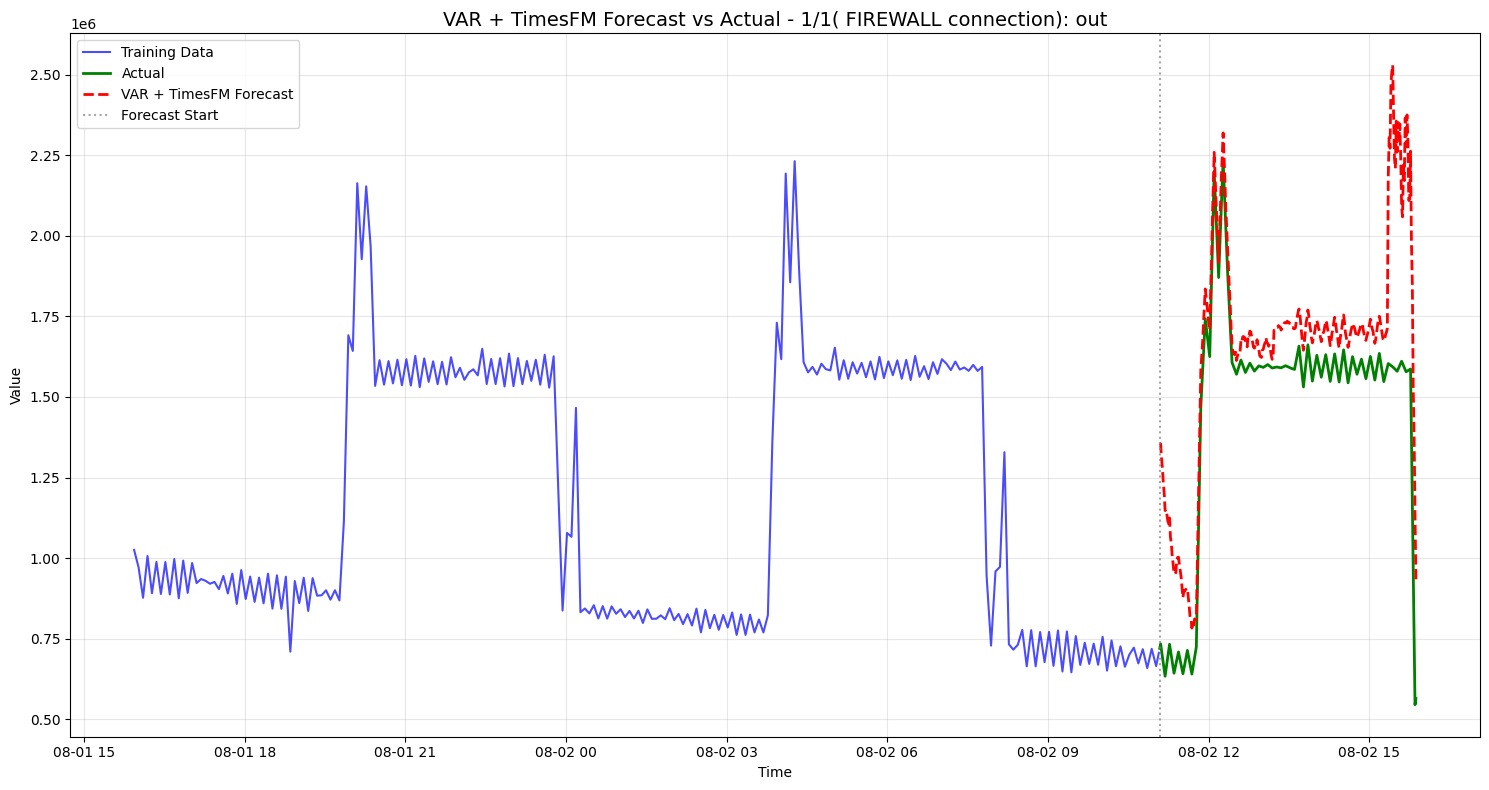

Metrics for 1/1( FIREWALL connection): out:
MAE: 192014.8157, RMSE: 276354.6166


In [17]:
results_df = pd.DataFrame(results)
plot_single_variable_forecast(
    variable_idx=1,
    train_data_normalized=train_data_normalized,
    test_data_denormalized=test_data_denormalized,
    forecast_denormalized=VAR_forecast_with_residuals,
    scaler=scaler,
    results_df=results_df
)